In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# Lightly adapted from https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb

# Automatically generating object masks with SAM

Since SAM 2 can efficiently process prompts, masks for the entire image can be generated by sampling a large number of prompts over an image.

The class `SAM2AutomaticMaskGenerator` implements this capability. It works by sampling single-point input prompts in a grid over the image, from each of which SAM can predict multiple masks. Then, masks are filtered for quality and deduplicated using non-maximal suppression. Additional options allow for further improvement of mask quality and quantity, such as running prediction on multiple crops of the image or postprocessing masks to remove small disconnected regions and holes.

<a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam2/blob/main/notebooks/automatic_mask_generator_example.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Environment Set-up

If running locally using jupyter, first install `SAM 2` in your environment using the installation instructions in the repository.

If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'. Note that it's recommended to use **A100 or L4 GPUs when running in Colab** (T4 GPUs might also work, but could be slow and might run out of memory in some cases).

In [2]:
using_colab = False

In [3]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

    !mkdir -p images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/cars.jpg

    !mkdir -p ../checkpoints/
    !wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

## Set-up

In [4]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # quite nice life hack
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from skimage.measure import regionprops
import pandas as pd

In [5]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "\ngive numerically different outputs and sometimes degraded performance on MPS. "
        "\nSee e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: mps

Support for MPS devices is preliminary. SAM 2 is trained with CUDA and might 
give numerically different outputs and sometimes degraded performance on MPS. 
See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion.


In [6]:
from matplotlib import colormaps
import cv2
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return

    sorted_anns = sorted(anns, key=lambda x: x['area'], reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img_shape = sorted_anns[0]['segmentation'].shape
    img = np.ones((*img_shape, 4))  # RGBA image
    img[:, :, 3] = 0  # Fully transparent initially

    cmap = colormaps.get_cmap("plasma")  # Get the plasma colormap
    num_colors = len(sorted_anns)  # Number of different colors needed
    color_indices = np.random.rand(num_colors)  # Randomly sample colors

    for i, ann in enumerate(sorted_anns):
        m = ann['segmentation']
        color = cmap(color_indices[i])  # Get a random color from plasma colormap
        color_mask = np.array([color[0], color[1], color[2], 0.5])  # RGBA with alpha

        img[m] = color_mask  # Assign color to segmentation mask

        if borders:
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1)  # Draw blue borders

    ax.imshow(img)

## Example image

In [8]:
folder_path = "/Volumes/warm_SD/03_FVG_optisch/200/0_Schliff/01_50x"
image_list = sorted(os.listdir(folder_path))
print(image_list)

['1.bmp', '10.bmp', '11.bmp', '12.bmp', '13.bmp', '14.bmp', '15.bmp', '2.bmp', '3.bmp', '4.bmp', '5.bmp', '6.bmp', '7.bmp', '8.bmp', '9.bmp', 'Panorama_200_01_50x.jpg', 'Thumbs.db']


In [33]:
file_name = image_list[3]
file_path = os.path.join(folder_path,file_name)

image = Image.open(file_path)
image = np.array(image.convert("RGB"))
print(image.shape)

(1920, 2560, 3)


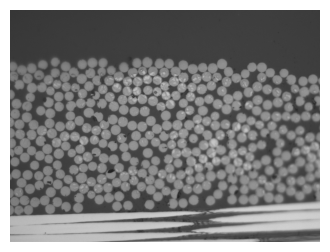

In [34]:
plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis('off')
plt.show()

In [35]:
## center crop the image
def center_crop_np(image: np.ndarray, crop_size=1024):
    """Fast center crop for a NumPy image.
    
    Args:
        image (np.ndarray): Input image as a NumPy array (H, W) or (H, W, C).
        crop_size (int): Target crop size (assumes square crop).
    
    Returns:
        np.ndarray: Center-cropped image.
    """
    h, w = image.shape[:2]  # Get height and width
    ch, cw = crop_size, crop_size  # Crop size

    # Compute center crop coordinates
    start_h = max((h - ch) // 2, 0)
    start_w = max((w - cw) // 2, 0)
    end_h = min(start_h + ch, h)
    end_w = min(start_w + cw, w)

    return image[start_h:end_h, start_w:end_w]

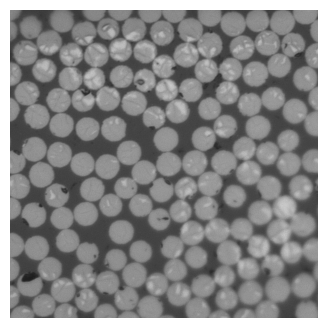

In [36]:
image = center_crop_np(image)

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis('off')
plt.show()

To run automatic mask generation, provide a version of SAM 2 to the `SAM2AutomaticMaskGenerator` class. Set the path below to the SAM 2 checkpoint.

In [37]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(
        model=sam2,
        points_per_side=48,
        # points_per_batch=96,
        pred_iou_thresh=0.1,
        # min_mask_region_area=500,
        box_nms_thresh=0.1,
        stability_score_thresh=0.95,  # Reduce the stability threshold to keep more masks
            )

To generate masks, just run `generate` on an image.

In [38]:
masks = mask_generator.generate(image)

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:
* `segmentation` : the mask
* `area` : the area of the mask in pixels
* `bbox` : the boundary box of the mask in XYWH format
* `predicted_iou` : the model's own prediction for the quality of the mask
* `point_coords` : the sampled input point that generated this mask
* `stability_score` : an additional measure of mask quality
* `crop_box` : the crop of the image used to generate this mask in XYWH format

Worst predicted_iou: 0.9056719541549683
Best predicted_iou: 0.982923686504364


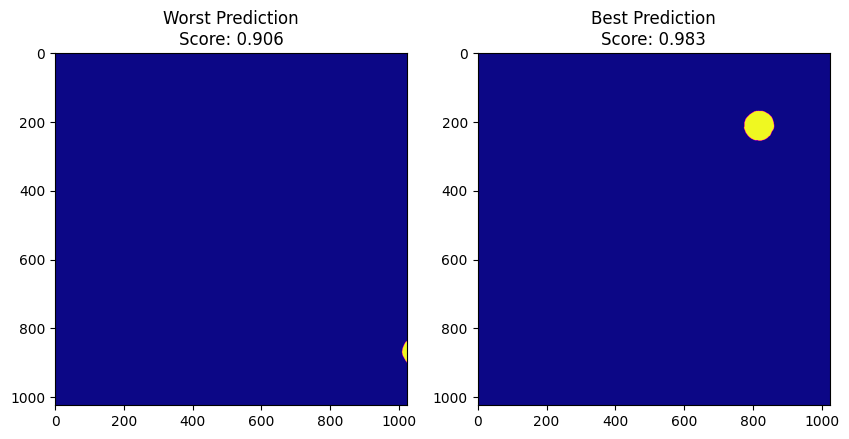

In [39]:
# Sort masks by stability score
sorted_masks = sorted(masks, key=lambda x: x["area"])

# Get the worst (lowest stability score) and best (highest stability score)
worst_mask = sorted_masks[2]   # First entry is the lowest stability score
best_mask = sorted_masks[-1]   # Last entry is the highest stability score

# Print stability scores
print(f"Worst predicted_iou: {worst_mask['predicted_iou']}")
print(f"Best predicted_iou: {best_mask['predicted_iou']}")

# Plot both masks
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(worst_mask["segmentation"], cmap="plasma")
axes[0].set_title(f"Worst Prediction\nScore: {worst_mask['predicted_iou']:.3f}")

axes[1].imshow(best_mask["segmentation"], cmap="plasma")
axes[1].set_title(f"Best Prediction\nScore: {best_mask['predicted_iou']:.3f}")

plt.show()

In [24]:
del sorted_masks[-1]

Show all the masks overlayed on the image.

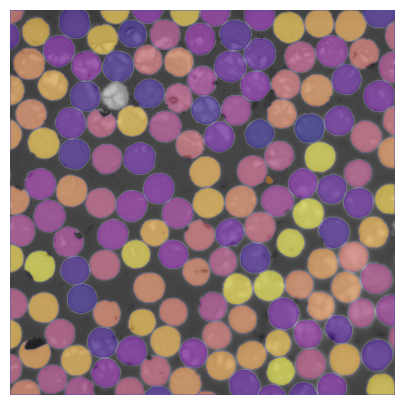

In [40]:
plt.figure(figsize=(5, 5))
plt.imshow(image)
show_anns(sorted_masks)
plt.axis('off')
plt.show() 

In [26]:
# Create an empty instance map (same size as the image)
instance_map = np.zeros_like(sorted_masks[0]["segmentation"], dtype=np.uint16)

# Assign unique labels to each detected mask
for i, mask in enumerate(sorted_masks):
    instance_map[mask["segmentation"] > 0] =  1+i # Labels start from 1

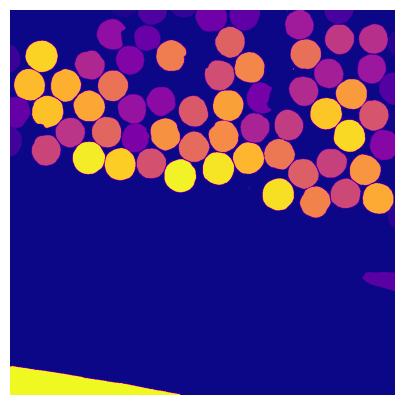

In [27]:
plt.figure(figsize=(5, 5))
plt.imshow(instance_map,cmap="plasma")
plt.axis('off')
plt.show() 

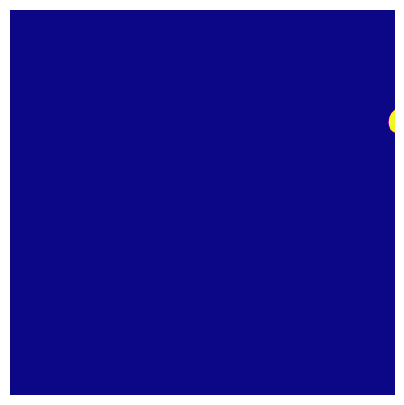

In [28]:
plt.figure(figsize=(5, 5))
plt.imshow(sorted_masks[0]["segmentation"],cmap="plasma")
plt.axis('off')
plt.show() 

In [29]:
properties = [
    'area', 'bbox', 'bbox_area', 'centroid', 'convex_area', 'eccentricity',
    'equivalent_diameter', 'euler_number', 'extent', 'feret_diameter_max',
    'filled_area', 'label', 'major_axis_length', 'minor_axis_length',
    'orientation', 'perimeter', 'solidity'
]

# Extract region properties
regions = regionprops(instance_map)

region_data = []

for region in regions:
    region_dict = {prop: getattr(region, prop) for prop in properties}
    region_dict["Orientation (deg)"] = np.degrees(region_dict["orientation"])  # Convert to degrees
    region_data.append(region_dict)

# Convert to DataFrame
df = pd.DataFrame(region_data)
df.head()

,area,bbox,bbox_area,centroid,convex_area,eccentricity,equivalent_diameter,euler_number,extent,feret_diameter_max,filled_area,label,major_axis_length,minor_axis_length,orientation,perimeter,solidity,Orientation (deg)
0,751.0,"(266, 1007, 326, 1024)",1020.0,"(296.5166444740346, 1016.4940079893476)",771.0,0.951748,30.922531,1,0.736275,60.033324,751.0,1,57.803837,17.738907,-0.017987,134.183766,0.974060,-1.030564
1,882.0,"(0, 270, 18, 335)",1170.0,"(7.010204081632653, 302.2120181405896)",899.0,0.952956,33.511152,1,0.753846,65.069194,882.0,2,63.183485,19.151546,-1.570221,145.597980,0.981090,-89.967056
2,888.0,"(56, 1006, 121, 1024)",1170.0,"(88.54054054054055, 1015.9481981981982)",907.0,0.953125,33.624942,1,0.758974,65.069194,888.0,3,63.310674,19.156424,-0.007978,145.597980,0.979052,-0.457084
3,917.0,"(514, 1005, 581, 1024)",1273.0,"(546.9574700109051, 1015.73173391494)",938.0,0.948571,34.169587,1,0.720346,67.067131,917.0,4,63.463788,20.090318,-0.007436,149.840620,0.977612,-0.426064
4,947.0,"(0, 429, 20, 494)",1300.0,"(7.700105596620908, 461.583949313622)",964.0,0.941679,34.724024,1,0.728462,65.030762,947.0,5,62.160139,20.917633,1.556840,147.254834,0.982365,89.200384


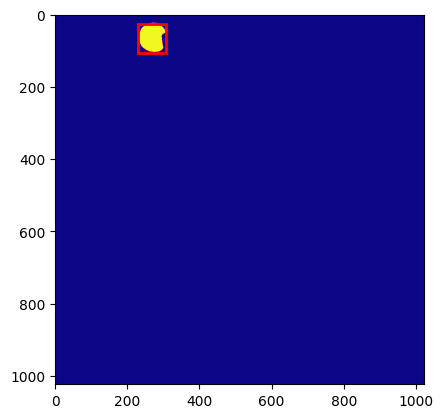

In [30]:
import matplotlib.patches as patches
# Bounding box coordinates
min_row, min_col, max_row, max_col = df["bbox"][20]

# Plot image
fig, ax = plt.subplots()
ax.imshow(sorted_masks[20]["segmentation"],cmap="plasma")

# Create a rectangle patch
rect = patches.Rectangle((min_col, min_row),  # (x_min, y_min)
                         max_col - min_col,   # width
                         max_row - min_row,   # height
                         linewidth=2, edgecolor='r', facecolor='none')

# Add the rectangle to the axes
ax.add_patch(rect)

# Show the plot
plt.show()


In [31]:
import tifffile
### Export:
file_name_dir = os.path.join(os.path.splitext(file_name)[0])
out_dir = os.path.join("results",file_name_dir)

os.makedirs(out_dir,exist_ok=True)


## write image 
tifffile.imwrite(os.path.join(out_dir,file_name_dir + ".raw.tiff"), image.astype(np.uint8), imagej=True)
## write regionprops results as excel
df.to_excel(os.path.join(out_dir,file_name_dir + ".props.xlsx"),index=False)


## write label mask
## uint8 only 255 fiber segementations possible ! Otherwise change to uint16
tifffile.imwrite(os.path.join(out_dir,file_name_dir + ".labels.tiff"), instance_map.astype(np.uint8), imagej=True)


## write individual masks as tiff-stack
## uint8 only 255 fiber segementations possible ! Otherwise change to uint16
# Create an empty instance map (same size as the image)
height, width = masks[0]["segmentation"].shape  # Get image dimensions
masks_maps = np.zeros((len(sorted_masks), height, width), dtype=np.uint8)  # Create 3D array

    # Assign unique labels to each mask in a separate layer
for i, mask in enumerate(sorted_masks):
    masks_maps[i][mask["segmentation"] > 0] = i + 1  # Labels start from 1

tifffile.imwrite(os.path.join(out_dir,file_name_dir + ".masks.tiff"), masks_maps.astype(np.uint8), imagej=True)


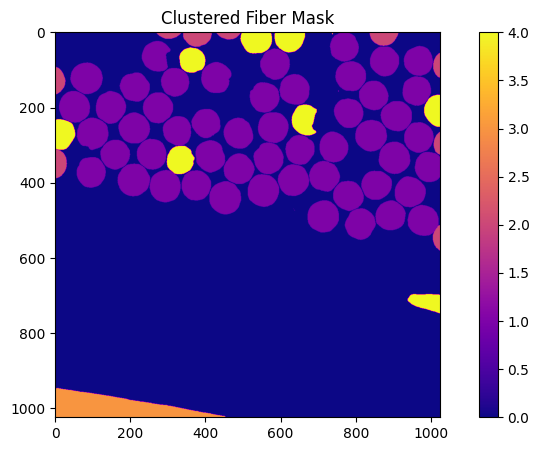

In [32]:
from sklearn.cluster import KMeans
features = df[["area"]].values

# Normalize features (optional but improves clustering)
features = (features - features.mean(axis=0)) / features.std(axis=0)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
df["Cluster"] = kmeans.fit_predict(features)



clustered_map = np.zeros_like(instance_map, dtype=np.uint8)
    
# Assign unique colors to clusters
cluster_colors = {0: 1, 1: 2, 2:3, 3:4}  # Example: Two intensity levels for 2 clusters

for _, row in df.iterrows():
    clustered_map[instance_map == row["label"]] = cluster_colors[row["Cluster"]]

# Display the clustered mask
plt.figure(figsize=(10, 5))
plt.imshow(clustered_map, cmap="plasma")
plt.colorbar()
plt.title("Clustered Fiber Mask")
plt.show()


In [71]:
np.unique(df["Cluster"])

array([0, 1, 2, 3], dtype=int32)

## Automatic mask generation options

There are several tunable parameters in automatic mask generation that control how densely points are sampled and what the thresholds are for removing low quality or duplicate masks. Additionally, generation can be automatically run on crops of the image to get improved performance on smaller objects, and post-processing can remove stray pixels and holes. Here is an example configuration that samples more masks:

In [ ]:
mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.7,
    stability_score_thresh=0.92,
    stability_score_offset=0.7,
    crop_n_layers=1,
    box_nms_thresh=0.7,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=25.0,
    use_m2m=True,
)

In [ ]:
masks2 = mask_generator_2.generate(image)

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.show() 